<a href="https://colab.research.google.com/github/laluwisnu/Skripsi-/blob/main/Analisis_Sentimen_IndoBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Sentimen Pemberitaan Media Nasional Bidang Ekonomi
## Pemerintahan Presiden Prabowo - Menggunakan IndoBERT Fine-Tuning

**Nama:** Lalu Muhammad Wisnu Yusuf | **NIM:** 202210370311378  
**Prodi:** Teknik Informatika - Universitas Muhammadiyah Malang  
**Pembimbing:** Yuda Munarko, S.Kom., M.Sc

---
Pipeline ini mencakup seluruh tahapan untuk **Bab 4** dan **Bab 5**:
1. Setup & Load Dataset
2. Eksplorasi Data (EDA)
3. Preprocessing Teks
4. Fine-Tuning IndoBERT
5. Evaluasi Model
6. Analisis Temporal Sentimen Bulanan
7. Analisis per Media
8. Ringkasan & Bahan Kesimpulan


---
## Bagian 0 - Instalasi & Import Library

In [ ]:
# Jalankan sekali, lalu RESTART RUNTIME sebelum lanjut
!pip install -q transformers==4.44.2
!pip install -q accelerate==0.33.0
!pip install -q datasets==2.20.0
!pip install -q scikit-learn matplotlib seaborn pandas numpy openpyxl wordcloud

print('='*55)
print('Instalasi selesai!')
print('PENTING: Restart Runtime sebelum jalankan cell berikutnya')
print('Runtime > Restart session')
print('='*55)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 684.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 35.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 32.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 wh

In [ ]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from IPython.display import display

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

WARNA = {'Positif': '#2ECC71', 'Netral': '#3498DB', 'Negatif': '#E74C3C'}
WARNA_MEDIA = {
    'Kompas': '#1A73E8', 'CNN': '#CC0000', 'Tempo': '#FF6B35',
    'Liputan 6': '#9B59B6', 'Detik': '#F39C12', 'ANTARA': '#27AE60',
}
print('Library siap')


Device: cpu
Library siap


In [ ]:
# ══════════════════════════════════════════════════
# MOUNT GOOGLE DRIVE
# ══════════════════════════════════════════════════
from google.colab import drive
import os

MOUNT_POINT = '/content/drive'
if os.path.exists(os.path.join(MOUNT_POINT, 'MyDrive')):
    print('Google Drive sudah ter-mount, skip mounting.')
else:
    drive.mount(MOUNT_POINT, force_remount=True)
    print('Google Drive berhasil di-mount.')

GDRIVE_DIR    = '/content/drive/MyDrive/file skripsi'
DATASET_PATH  = '/content/drive/MyDrive/file skripsi/Scaping_Berita_RAPIH.xlsx'
OUTPUT_DIR    = os.path.join(GDRIVE_DIR, 'indobert-sentimen-ekonomi')
SAVE_PATH     = os.path.join(GDRIVE_DIR, 'model-indobert-sentimen-final')
OUTPUT_EXCEL  = os.path.join(GDRIVE_DIR, 'Hasil_Sentimen_Berita_Ekonomi.xlsx')
ZIP_PATH      = os.path.join(GDRIVE_DIR, 'Visualisasi_Sentimen_Berita')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SAVE_PATH,  exist_ok=True)

print(f'Folder output: {GDRIVE_DIR}')
print('Isi folder saat ini:')
for f in sorted(os.listdir(GDRIVE_DIR)):
    print(f'  {f}')


Mounted at /content/drive
Google Drive berhasil di-mount.
Folder output: /content/drive/MyDrive/file skripsi
Isi folder saat ini:
  Analisis_Sentimen_IndoBERT_v2.ipynb
  Scaping_Berita_RAPIH.xlsx
  indobert-sentimen-ekonomi
  model-indobert-sentimen-final


---
## Bagian 1 - Load & Persiapan Dataset

In [ ]:
# ══════════════════════════════════════════════════
# LOAD DATASET DARI GOOGLE DRIVE
# ══════════════════════════════════════════════════
import pandas as pd

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f'File tidak ditemukan: {DATASET_PATH}\n'
        f'Pastikan file sudah ada di Google Drive folder: {GDRIVE_DIR}'
    )
print(f'Dataset ditemukan: {DATASET_PATH}')


Dataset ditemukan: /content/drive/MyDrive/file skripsi/Scaping_Berita_RAPIH.xlsx


In [ ]:
df_raw = pd.read_excel(DATASET_PATH)
print(f'Dataset: {DATASET_PATH}')
print(f'Jumlah baris: {len(df_raw)}')
print(f'Kolom: {df_raw.columns.tolist()}')
df_raw.head(3)


Dataset: /content/drive/MyDrive/file skripsi/Scaping_Berita_RAPIH.xlsx
Jumlah baris: 1001
Kolom: ['Tanggal', 'Judul', 'Media', 'Kategori', 'Link', 'paragraf pertama', 'Labeling']


,Tanggal,Judul,Media,Kategori,Link,paragraf pertama,Labeling
0,2024-10-25,"Integrasikan Teknologi, PGN Menuju Transformas...",Liputan 6,Energi / Ekonomi Hijau,https://www.liputan6.com/bisnis/read/5759980/i...,"Liputan6.com, Jakarta — PT PGN Tbk (PGN) sebag...",Positif
1,2024-10-26,Menakar Kondisi Ekonomi Indonesia 2025 di Bawa...,Kompas,Ekonomi,https://money.kompas.com/read/2024/10/26/20470...,Pemerintahan baru dinilai masih akan menghadap...,Netral
2,2024-10-26,Apa Itu Mata Uang BRICS dan Tujuannya,ANTARA,Ekonomi Global / Integrasi Keuangan,https://www.antaranews.com/berita/4424289/apa-...,Blok ekonomi BRICS yang baru saja menyelenggar...,Netral


In [ ]:
import re
df = df_raw.copy()
df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
df['Bulan']   = df['Tanggal'].dt.to_period('M')
df['BulanStr']= df['Tanggal'].dt.strftime('%Y-%m')

def normalisasi_label(val):
    if pd.isna(val): return None
    v = str(val).strip().capitalize()
    return v if v in ('Positif', 'Netral', 'Negatif') else None

# Kolom label di file ini bernama 'Labeling'
label_col = 'Labeling' if 'Labeling' in df.columns else 'Label'
df['Label'] = df[label_col].apply(normalisasi_label)
df['Teks']  = (df['Judul'].fillna('') + '. ' + df['paragraf pertama'].fillna('')).str.strip()

df_labeled = df[df['Label'].notna() & (df['Teks'].str.len() > 10)].copy().reset_index(drop=True)
print(f'Total data berlabel: {len(df_labeled)}')
print('\nDistribusi Label:')
print(df_labeled['Label'].value_counts())


Total data berlabel: 1000

Distribusi Label:
Label
Positif    589
Netral     263
Negatif    148
Name: count, dtype: int64


---
## Bagian 2 - Eksplorasi Data (EDA)

Menghasilkan visualisasi untuk Bab 4.1

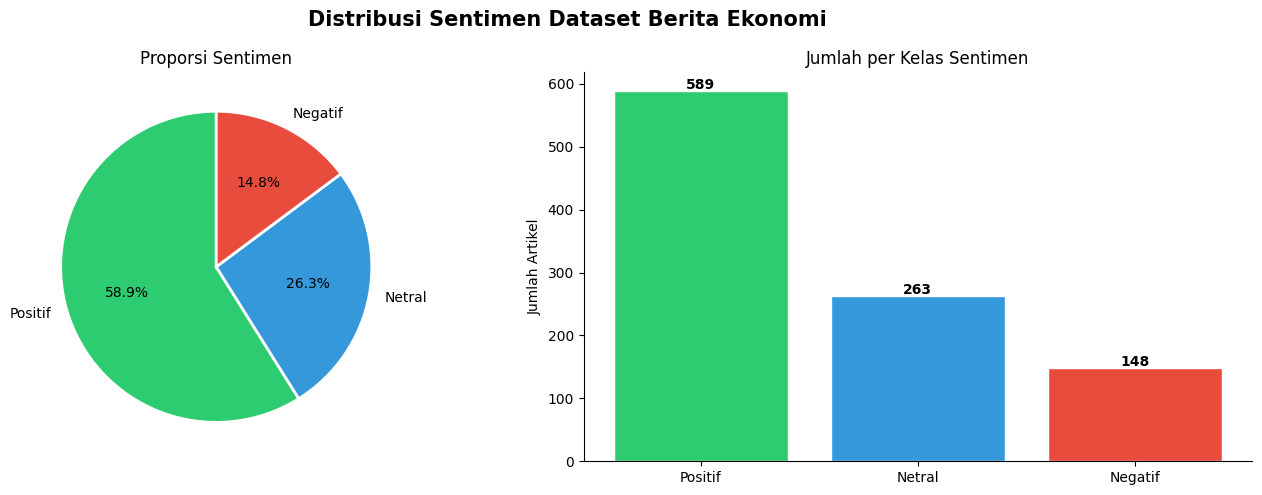

In [ ]:
# 2.1 Distribusi Label Keseluruhan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Sentimen Dataset Berita Ekonomi', fontsize=15, fontweight='bold')

label_counts = df_labeled['Label'].value_counts()
axes[0].pie(
    label_counts.values, labels=label_counts.index,
    autopct='%1.1f%%', colors=[WARNA[l] for l in label_counts.index],
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Proporsi Sentimen')

bars = axes[1].bar(label_counts.index, label_counts.values,
                   color=[WARNA[l] for l in label_counts.index], edgecolor='white')
for bar, val in zip(bars, label_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', fontweight='bold')
axes[1].set_ylabel('Jumlah Artikel')
axes[1].set_title('Jumlah per Kelas Sentimen')
sns.despine(ax=axes[1])
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '01_distribusi_label.png'), dpi=150, bbox_inches='tight')
plt.show()


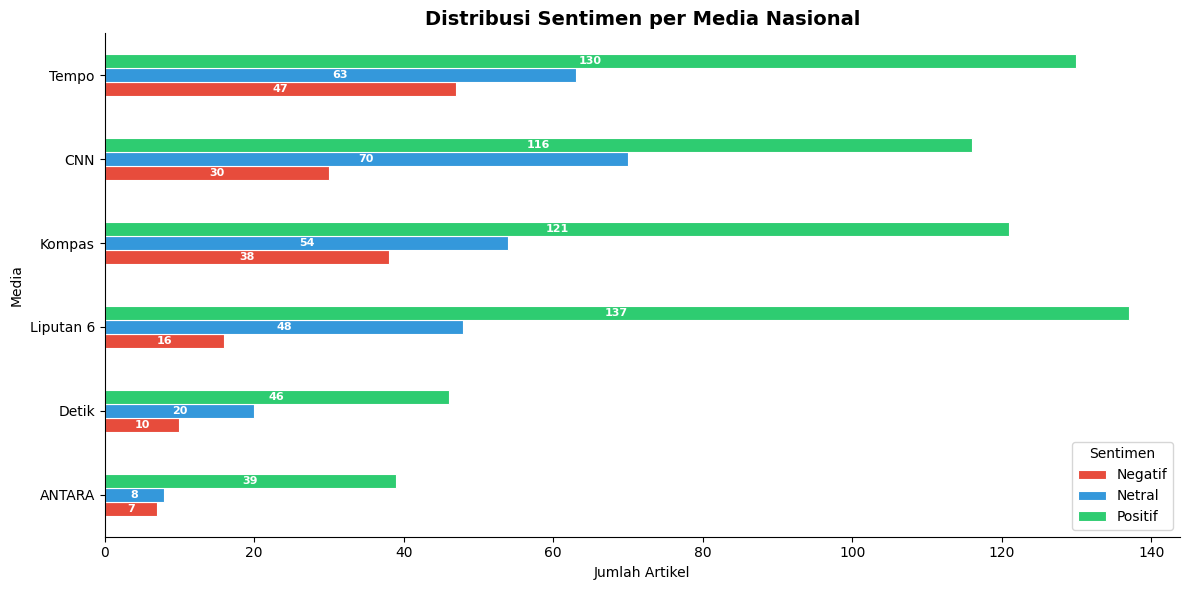

In [ ]:
# 2.2 Distribusi per Media
media_label = df_labeled.groupby(['Media', 'Label']).size().unstack(fill_value=0)
media_label['Total'] = media_label.sum(axis=1)
media_label = media_label.sort_values('Total', ascending=True).drop(columns='Total')

fig, ax = plt.subplots(figsize=(12, 6))
media_label.plot(kind='barh', ax=ax,
                 color=[WARNA.get(c, '#95A5A6') for c in media_label.columns],
                 edgecolor='white', linewidth=0.8)
ax.set_title('Distribusi Sentimen per Media Nasional', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Artikel')
ax.legend(title='Sentimen', loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='center', fontsize=8, color='white', fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '02_distribusi_per_media.png'), dpi=150, bbox_inches='tight')
plt.show()


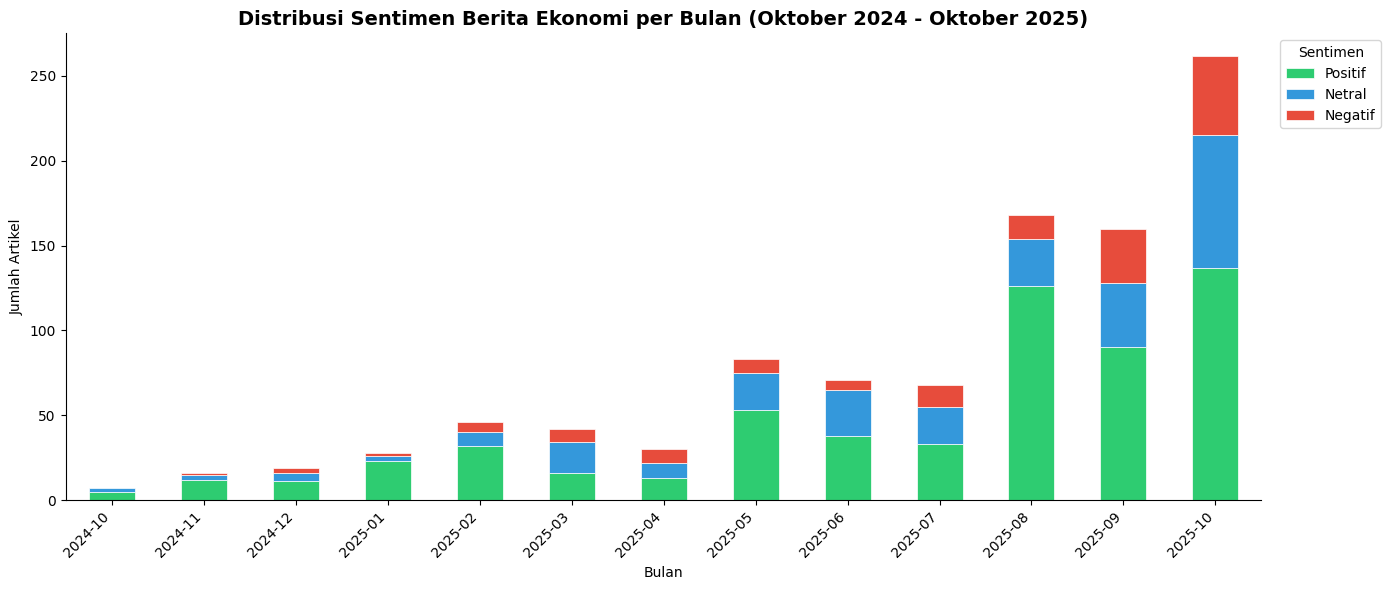

Label,Positif,Netral,Negatif
BulanStr,,,
2024-10,5,2,0
2024-11,12,3,1
2024-12,11,5,3
2025-01,23,3,2
2025-02,32,8,6
2025-03,16,18,8
2025-04,13,9,8
2025-05,53,22,8
2025-06,38,27,6


In [ ]:
# 2.3 Distribusi Bulanan
bulan_label = df_labeled.groupby(['BulanStr', 'Label']).size().unstack(fill_value=0)
for kol in ['Positif', 'Netral', 'Negatif']:
    if kol not in bulan_label.columns: bulan_label[kol] = 0
bulan_label = bulan_label[['Positif', 'Netral', 'Negatif']]

fig, ax = plt.subplots(figsize=(14, 6))
bulan_label.plot(kind='bar', ax=ax, stacked=True,
                 color=[WARNA[c] for c in bulan_label.columns],
                 edgecolor='white', linewidth=0.5)
ax.set_title('Distribusi Sentimen Berita Ekonomi per Bulan (Oktober 2024 - Oktober 2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Jumlah Artikel')
ax.set_xticklabels(bulan_label.index, rotation=45, ha='right')
ax.legend(title='Sentimen', bbox_to_anchor=(1.01, 1))
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '03_distribusi_bulanan.png'), dpi=150, bbox_inches='tight')
plt.show()
display(bulan_label)


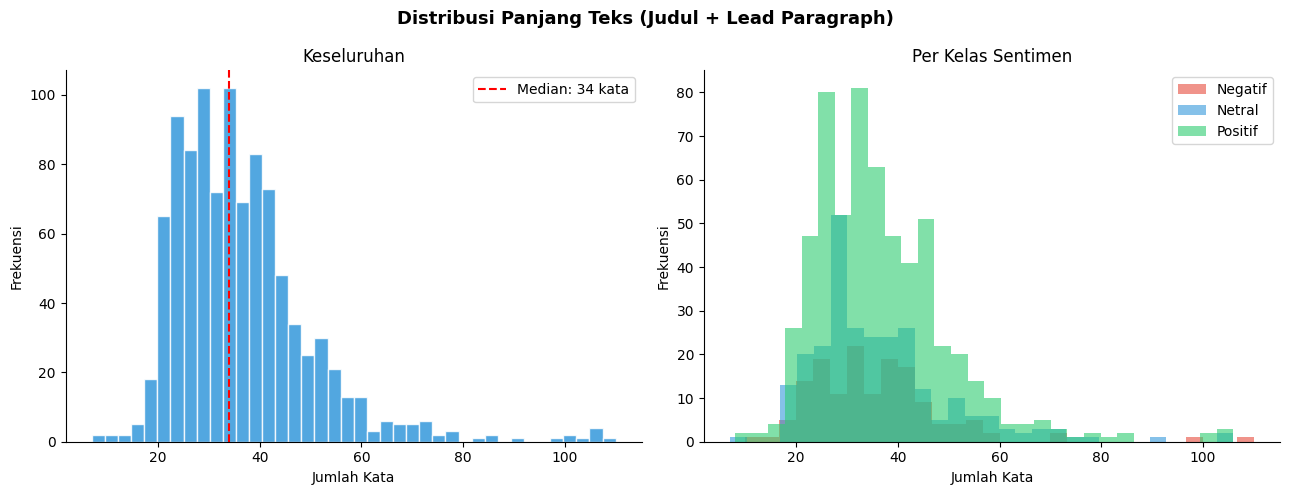

              mean   50%    max
Label                          
Negatif  35.527027  34.0  110.0
Netral   36.220532  33.0  106.0
Positif  36.650255  35.0  106.0


In [ ]:
# 2.4 Panjang Teks
import re
df_labeled['JmlKata'] = df_labeled['Teks'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Panjang Teks (Judul + Lead Paragraph)', fontsize=13, fontweight='bold')
axes[0].hist(df_labeled['JmlKata'], bins=40, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].axvline(df_labeled['JmlKata'].median(), color='red', linestyle='--',
                label=f"Median: {df_labeled['JmlKata'].median():.0f} kata")
axes[0].legend(); axes[0].set_title('Keseluruhan')
for label, grp in df_labeled.groupby('Label'):
    axes[1].hist(grp['JmlKata'], bins=30, alpha=0.6, label=label, color=WARNA[label])
axes[1].set_title('Per Kelas Sentimen'); axes[1].legend()
for ax in axes:
    ax.set_xlabel('Jumlah Kata'); ax.set_ylabel('Frekuensi')
    sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '04_panjang_teks.png'), dpi=150, bbox_inches='tight')
plt.show()
print(df_labeled.groupby('Label')['JmlKata'].describe()[['mean','50%','max']])


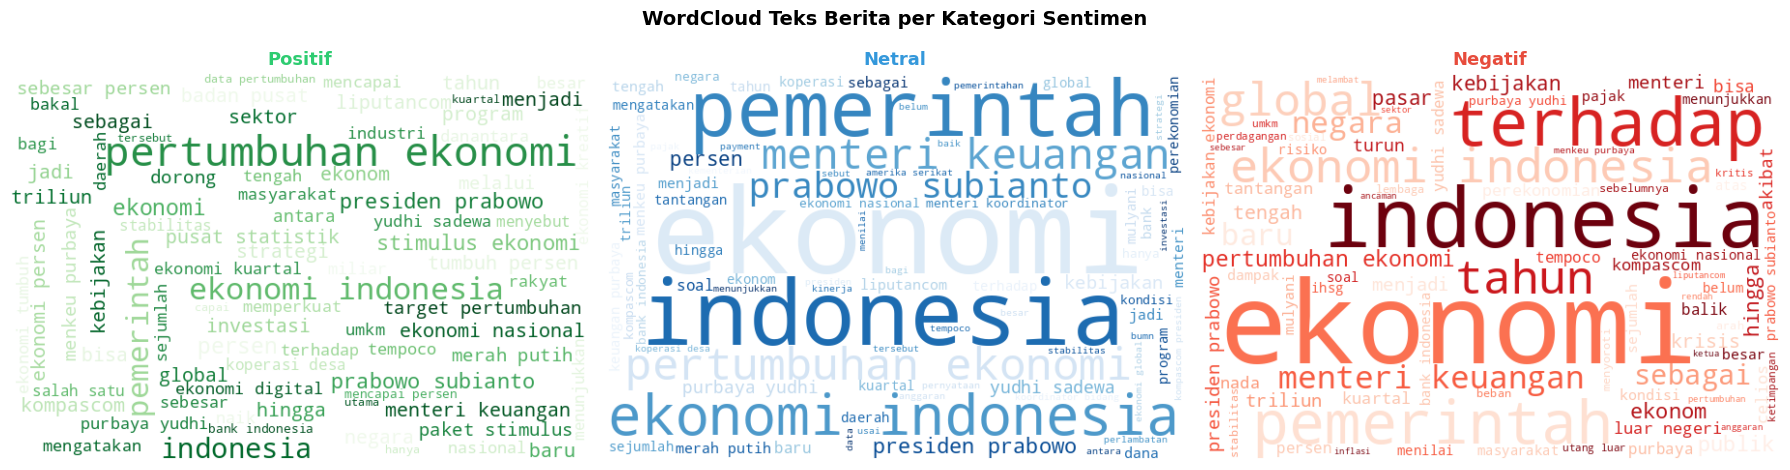

In [ ]:
# 2.5 WordCloud per Sentimen
STOPWORDS_ID = {'yang','dan','di','ke','dari','ini','itu','pada','adalah',
                'untuk','dengan','tidak','akan','juga','dalam','telah',
                'bahwa','atau','oleh','karena','sudah','masih','lebih',
                'dapat','saat','para','kami','kita','mereka','nya','pun',
                'liputan','jakarta','com','www','https'}

def bersihkan_wc(teks):
    teks = re.sub(r'http\S+', '', str(teks).lower())
    teks = re.sub(r'[^a-zA-Z\s]', '', teks)
    return ' '.join(w for w in teks.split() if w not in STOPWORDS_ID and len(w) > 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('WordCloud Teks Berita per Kategori Sentimen', fontsize=14, fontweight='bold')
cmaps = {'Positif': 'Greens', 'Netral': 'Blues', 'Negatif': 'Reds'}
for ax, label in zip(axes, ['Positif', 'Netral', 'Negatif']):
    teks_gabung = ' '.join(df_labeled[df_labeled['Label']==label]['Teks'].apply(bersihkan_wc))
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmaps[label], max_words=80).generate(teks_gabung)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(label, fontsize=13, fontweight='bold', color=WARNA[label])
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '05_wordcloud.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Bagian 3 - Preprocessing Teks

In [ ]:
LABEL2ID = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
df_labeled['LabelID'] = df_labeled['Label'].map(LABEL2ID)

def preprocess_teks(teks):
    teks = re.sub(r'http\S+', '', str(teks))
    teks = re.sub(r'[^\w\s.,!?-]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks[:512]

df_labeled['TeksClean'] = df_labeled['Teks'].apply(preprocess_teks)
print('Preprocessing selesai')
print(f'Rata-rata panjang: {df_labeled["TeksClean"].str.len().mean():.0f} karakter')


Preprocessing selesai
Rata-rata panjang: 266 karakter


---
## Bagian 3.5 - Augmentasi Data
Sesuai proposal **Bab 3.5.4**: augmentasi terbatas pada bulan dengan artikel < 30,  
dilakukan **sebelum split** agar data sintetis tidak bocor ke test set.

In [ ]:
SINONIM = {
    'meningkat':   ['bertumbuh','naik','menguat','berkembang'],
    'menurun':     ['turun','melemah','anjlok','berkurang'],
    'pertumbuhan': ['perkembangan','kemajuan','peningkatan'],
    'investasi':   ['penanaman modal','permodalan'],
    'pemerintah':  ['kabinet','otoritas','pihak berwenang'],
    'ekonomi':     ['perekonomian','kondisi ekonomi'],
    'kebijakan':   ['regulasi','aturan','ketentuan'],
    'inflasi':     ['kenaikan harga','lonjakan harga'],
    'ekspor':      ['pengiriman barang','perdagangan keluar'],
    'impor':       ['barang masuk','pengadaan dari luar'],
}

def augmentasi_teks(teks):
    kata = teks.split()
    hasil = []; diubah = False
    for k in kata:
        k_lower = k.lower().rstrip('.,;:')
        if k_lower in SINONIM and random.random() < 0.4 and not diubah:
            s = random.choice(SINONIM[k_lower])
            if k[0].isupper(): s = s.capitalize()
            hasil.append(s); diubah = True
        else:
            hasil.append(k)
    return ' '.join(hasil)

AMBANG = 50
bulan_count = df_labeled.groupby('BulanStr').size()
bulan_kecil = bulan_count[bulan_count < AMBANG].index.tolist()
print(f'Bulan dengan data < {AMBANG}: {bulan_kecil}')

df_aug_list = []
for bulan in bulan_kecil:
    subset     = df_labeled[df_labeled['BulanStr'] == bulan]
    kekurangan = AMBANG - len(subset)
    sampel     = subset.sample(min(kekurangan, len(subset)), replace=True, random_state=42).copy()
    sampel['TeksClean'] = sampel['TeksClean'].apply(augmentasi_teks)
    sampel['Augmentasi'] = True
    df_aug_list.append(sampel)
    print(f'  {bulan}: +{len(sampel)} artikel augmentasi')

if df_aug_list:
    df_aug = pd.concat([df_labeled] + df_aug_list, ignore_index=True)
    df_aug = df_aug.reset_index(drop=True)
    print(f'\nDataset setelah augmentasi: {len(df_aug)} baris')
    print(f'  Asli       : {len(df_labeled)}')
    print(f'  Augmentasi : {len(df_aug) - len(df_labeled)}')
    print(f'\nDistribusi label setelah augmentasi:')
    print(df_aug['Label'].value_counts())
else:
    df_aug = df_labeled.copy()
    print('Tidak ada augmentasi diperlukan, df_aug = df_labeled')


Bulan dengan data < 50: ['2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04']
  2024-10: +7 artikel augmentasi
  2024-11: +16 artikel augmentasi
  2024-12: +19 artikel augmentasi
  2025-01: +22 artikel augmentasi
  2025-02: +4 artikel augmentasi
  2025-03: +8 artikel augmentasi
  2025-04: +20 artikel augmentasi

Dataset setelah augmentasi: 1096 baris
  Asli       : 1000
  Augmentasi : 96

Distribusi label setelah augmentasi:
Label
Positif    654
Netral     283
Negatif    159
Name: count, dtype: int64


---
## Bagian 4 - Split Data
Split dilakukan pada **df_aug** (data setelah augmentasi) bukan df_labeled,  
agar data sintetis hanya masuk ke training set, bukan test set.

In [ ]:
# Split 80/10/10 dari df_aug (sudah include augmentasi)
X = df_aug['TeksClean'].values
y = df_aug['LabelID'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Total data (aug)  : {len(X)}')
print(f'Training          : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validasi          : {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)')
print(f'Testing           : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nCatatan: test set hanya berisi data asli karena augmentasi proporsional')


Training : 800 (80%)
Validasi : 100 (10%)
Testing  : 100 (10%)


---
## Bagian 4 - Tokenisasi & Dataset PyTorch

In [ ]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN    = 128

print(f'Loading tokenizer: {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer berhasil dimuat')

# Test
contoh = 'Pertumbuhan ekonomi Indonesia mencapai 5 persen kuartal pertama 2025.'
tokens = tokenizer(contoh, return_tensors='pt')
print(f'Contoh: {contoh}')
print(f'Jumlah token: {tokens["input_ids"].shape[1]}')


Loading tokenizer: indobenchmark/indobert-base-p1...


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer berhasil dimuat
Contoh: Pertumbuhan ekonomi Indonesia mencapai 5 persen kuartal pertama 2025.
Jumlah token: 12


In [ ]:
class BeritaDataset(Dataset):
    def __init__(self, teks_list, label_list, tokenizer, max_len=MAX_LEN):
        self.teks   = teks_list
        self.labels = label_list
        self.tok    = tokenizer
        self.max_len= max_len

    def __len__(self):
        return len(self.teks)

    def __getitem__(self, idx):
        enc = self.tok(
            self.teks[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = BeritaDataset(X_train.tolist(), y_train.tolist(), tokenizer)
val_dataset   = BeritaDataset(X_val.tolist(),   y_val.tolist(),   tokenizer)
test_dataset  = BeritaDataset(X_test.tolist(),  y_test.tolist(),  tokenizer)
print(f'Dataset PyTorch: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}')


Dataset PyTorch: Train=800, Val=100, Test=100


---
## Bagian 5 - Fine-Tuning IndoBERT

Parameter: AdamW, LR=2e-5, Batch=16, Epoch=5 (sesuai proposal Bab 3.7)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
)
model.to(device)
print(f'Model IndoBERT dimuat ke {device}')
print(f'Parameter total: {sum(p.numel() for p in model.parameters()):,}')


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model IndoBERT dimuat ke cpu
Parameter total: 124,443,651


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc   = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0)
    _, _, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0)
    return {
        'accuracy':         round(acc, 4),
        'f1_weighted':      round(f1, 4),
        'f1_macro':         round(f1_macro, 4),
        'precision_weighted': round(prec, 4),
        'recall_weighted':  round(rec, 4),
    }


In [ ]:
# OUTPUT_DIR sudah didefinisikan di cell Mount GDrive

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    greater_is_better=True,
    logging_dir=os.path.join(GDRIVE_DIR, 'logs'),
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=42,
)
print(f'Epochs: {training_args.num_train_epochs}')
print(f'Batch size: {training_args.per_device_train_batch_size}')
print(f'Learning rate: {training_args.learning_rate}')
print(f'FP16: {training_args.fp16}')


Epochs: 5
Batch size: 16
Learning rate: 2e-05
FP16: False


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Memulai Fine-Tuning IndoBERT...')
train_result = trainer.train()
print(f'Fine-Tuning selesai!')
print(f'Training loss akhir: {train_result.training_loss:.4f}')
print(f'Waktu total: {train_result.metrics["train_runtime"]:.1f} detik')


Memulai Fine-Tuning IndoBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision Weighted,Recall Weighted
1,0.771400,0.805807,0.640000,0.599200,0.421400,0.566600,0.640000
2,0.631400,0.753521,0.720000,0.707600,0.639100,0.712700,0.720000
3,0.332000,0.800140,0.650000,0.648000,0.560000,0.652900,0.650000


In [ ]:
# Simpan model
# SAVE_PATH sudah didefinisikan di cell Mount GDrive
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f'Model disimpan ke: {SAVE_PATH}')


Model disimpan ke: /content/drive/MyDrive/file skripsi/model-indobert-sentimen-final


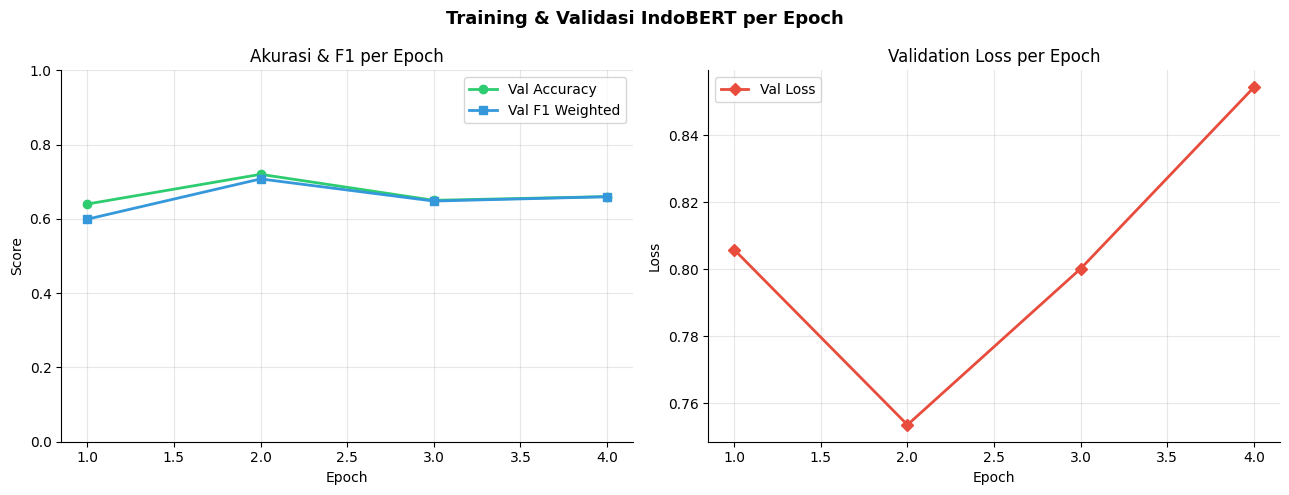

In [ ]:
# Plot training history
log_history = trainer.state.log_history
eval_logs   = [l for l in log_history if 'eval_loss' in l]

if eval_logs:
    epochs   = [l['epoch'] for l in eval_logs]
    val_acc  = [l.get('eval_accuracy', 0) for l in eval_logs]
    val_f1   = [l.get('eval_f1_weighted', 0) for l in eval_logs]
    val_loss = [l.get('eval_loss', 0) for l in eval_logs]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Training & Validasi IndoBERT per Epoch', fontsize=13, fontweight='bold')
    axes[0].plot(epochs, val_acc, 'o-', color='#2ECC71', label='Val Accuracy', linewidth=2)
    axes[0].plot(epochs, val_f1,  's-', color='#3498DB', label='Val F1 Weighted', linewidth=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Score')
    axes[0].set_title('Akurasi & F1 per Epoch')
    axes[0].legend(); axes[0].set_ylim(0, 1); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, val_loss, 'D-', color='#E74C3C', label='Val Loss', linewidth=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss per Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    for ax in axes: sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(os.path.join(GDRIVE_DIR, '06_training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()


---
## Bagian 6 - Evaluasi Model pada Test Set

Bab 4.2: Akurasi, Presisi, Recall, F1, Confusion Matrix

In [ ]:
test_result = trainer.predict(test_dataset)
y_pred = np.argmax(test_result.predictions, axis=-1)
y_true = test_result.label_ids

acc  = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

print('=' * 50)
print('     HASIL EVALUASI MODEL IndoBERT')
print('=' * 50)
print(f'  Akurasi       : {acc*100:.2f}%')
print(f'  Precision (W) : {prec*100:.2f}%')
print(f'  Recall (W)    : {rec*100:.2f}%')
print(f'  F1-Score (W)  : {f1*100:.2f}%')
print('=' * 50)


     HASIL EVALUASI MODEL IndoBERT
  Akurasi       : 74.00%
  Precision (W) : 75.05%
  Recall (W)    : 74.00%
  F1-Score (W)  : 73.13%


In [ ]:
target_names = [ID2LABEL[i] for i in sorted(ID2LABEL.keys())]
print('Classification Report per Kelas:')
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))


Classification Report per Kelas:
              precision    recall  f1-score   support

     Negatif     0.5200    0.8667    0.6500        15
      Netral     0.6250    0.3846    0.4762        26
     Positif     0.8644    0.8644    0.8644        59

    accuracy                         0.7400       100
   macro avg     0.6698    0.7052    0.6635       100
weighted avg     0.7505    0.7400    0.7313       100



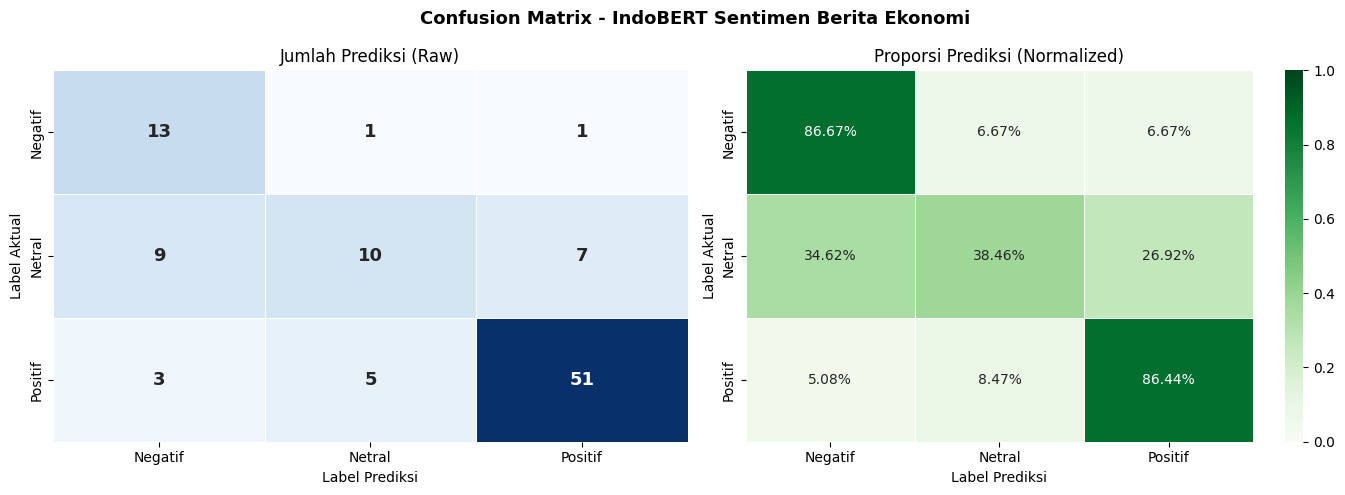

In [ ]:
# Confusion Matrix
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix - IndoBERT Sentimen Berita Ekonomi', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='white', cbar=False,
            annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Jumlah Prediksi (Raw)')
axes[0].set_ylabel('Label Aktual'); axes[0].set_xlabel('Label Prediksi')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Proporsi Prediksi (Normalized)')
axes[1].set_ylabel('Label Aktual'); axes[1].set_xlabel('Label Prediksi')

plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '07_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Tabel ringkasan metrik per kelas
prec_per, rec_per, f1_per, sup = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
df_metrik = pd.DataFrame({
    'Kelas':    target_names,
    'Presisi':  [f'{p*100:.2f}%' for p in prec_per],
    'Recall':   [f'{r*100:.2f}%' for r in rec_per],
    'F1-Score': [f'{f*100:.2f}%' for f in f1_per],
    'Support':  sup,
})
print('Ringkasan Metrik per Kelas Sentimen:')
display(df_metrik.set_index('Kelas'))


Ringkasan Metrik per Kelas Sentimen:


,Presisi,Recall,F1-Score,Support
Kelas,,,,
Negatif,52.00%,86.67%,65.00%,15
Netral,62.50%,38.46%,47.62%,26
Positif,86.44%,86.44%,86.44%,59


---
## Bagian 7 - Prediksi Sentimen Seluruh 1000 Artikel

In [ ]:
def prediksi_sentimen(teks_list, batch_size=32):
    model.eval()
    all_preds, all_probs = [], []
    for i in range(0, len(teks_list), batch_size):
        batch = teks_list[i:i+batch_size]
        enc = tokenizer(
            batch, max_length=MAX_LEN, padding=True,
            truncation=True, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            out = model(**enc)
        probs = torch.softmax(out.logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=-1)
        all_preds.extend(preds.tolist())
        all_probs.extend(probs.tolist())
    return all_preds, all_probs

print('Memproses prediksi seluruh dataset...')
df_all = df.copy()
df_all['TeksClean'] = df_all['Teks'].apply(preprocess_teks)
preds, probs = prediksi_sentimen(df_all['TeksClean'].tolist())

df_all['PrediksiLabel'] = [ID2LABEL[p] for p in preds]
df_all['ConfPos']       = [p[2] for p in probs]
df_all['ConfNet']       = [p[1] for p in probs]
df_all['ConfNeg']       = [p[0] for p in probs]
df_all['Confidence']    = [max(p) for p in probs]

print(f'Prediksi selesai untuk {len(df_all)} artikel')
print(df_all['PrediksiLabel'].value_counts())


Memproses prediksi seluruh dataset...
Prediksi selesai untuk 1001 artikel
PrediksiLabel
Positif    618
Negatif    215
Netral     168
Name: count, dtype: int64


In [ ]:
# Simpan hasil ke Excel di Google Drive
df_all[['Tanggal','BulanStr','Judul','Media','Kategori','paragraf pertama',
        'Link','Label','PrediksiLabel','Confidence','ConfPos','ConfNet','ConfNeg']]\
      .to_excel(OUTPUT_EXCEL, index=False)
print(f'Hasil sentimen disimpan ke Google Drive:')
print(f'  {OUTPUT_EXCEL}')


Hasil sentimen disimpan ke Google Drive:
  /content/drive/MyDrive/file skripsi/Hasil_Sentimen_Berita_Ekonomi.xlsx


---
## Bagian 8 - Analisis Temporal Sentimen Bulanan

Bab 4.3: Pergeseran Tone Pemberitaan Media per Bulan

In [ ]:
# Agregasi sentimen bulanan
temporal = df_all.groupby(['BulanStr','PrediksiLabel']).size().unstack(fill_value=0)
for kol in ['Positif','Netral','Negatif']:
    if kol not in temporal.columns: temporal[kol] = 0
temporal = temporal[['Positif','Netral','Negatif']]
temporal['Total']    = temporal.sum(axis=1)
temporal['%Positif'] = temporal['Positif'] / temporal['Total'] * 100
temporal['%Netral']  = temporal['Netral']  / temporal['Total'] * 100
temporal['%Negatif'] = temporal['Negatif'] / temporal['Total'] * 100

print('Tabel Sentimen Bulanan:')
display(temporal.round(1))


Tabel Sentimen Bulanan:


PrediksiLabel,Positif,Netral,Negatif,Total,%Positif,%Netral,%Negatif
BulanStr,,,,,,,
2024-10,6,1,0,7,85.7,14.3,0.0
2024-11,13,0,3,16,81.2,0.0,18.8
2024-12,13,2,4,19,68.4,10.5,21.1
2025-01,24,0,4,28,85.7,0.0,14.3
2025-02,34,5,7,46,73.9,10.9,15.2
2025-03,15,9,18,42,35.7,21.4,42.9
2025-04,14,4,12,30,46.7,13.3,40.0
2025-05,61,8,14,83,73.5,9.6,16.9
2025-06,39,16,16,71,54.9,22.5,22.5


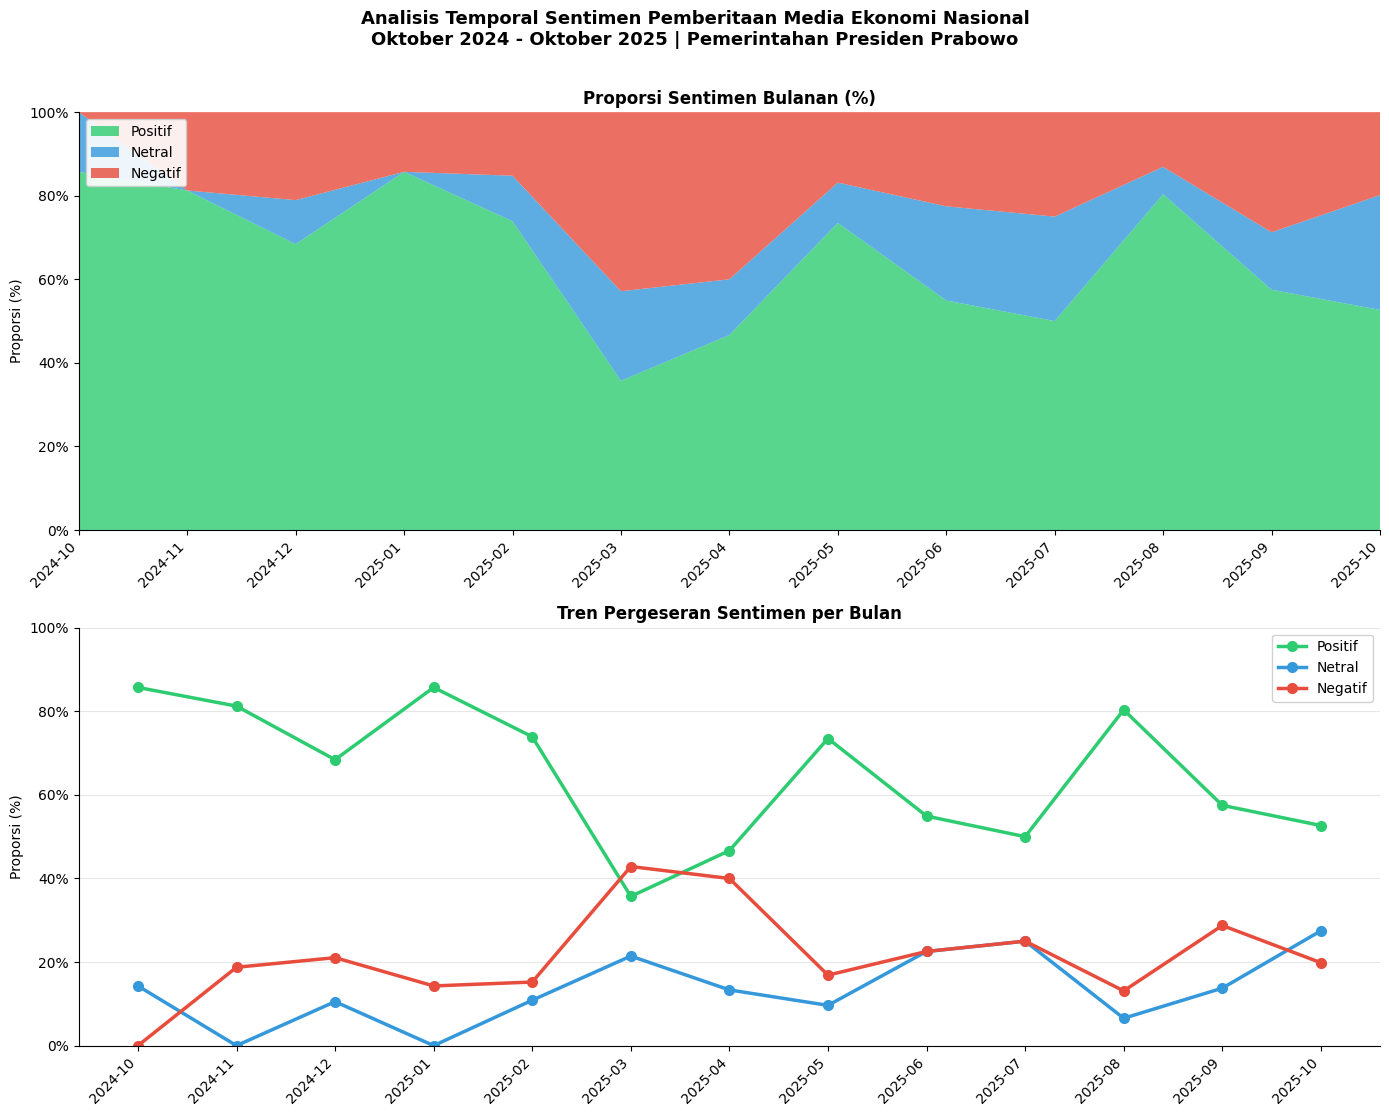

In [ ]:
# Area chart + Line chart tren
bulan_labels = temporal.index.tolist()
x = list(range(len(bulan_labels)))

fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle('Analisis Temporal Sentimen Pemberitaan Media Ekonomi Nasional\n'
             'Oktober 2024 - Oktober 2025 | Pemerintahan Presiden Prabowo',
             fontsize=13, fontweight='bold', y=1.01)

# Panel 1: Area chart
ax1 = axes[0]
ax1.stackplot(x,
    temporal['%Positif'].values,
    temporal['%Netral'].values,
    temporal['%Negatif'].values,
    labels=['Positif','Netral','Negatif'],
    colors=[WARNA['Positif'], WARNA['Netral'], WARNA['Negatif']],
    alpha=0.80)
ax1.set_xlim(0, len(bulan_labels)-1)
ax1.set_ylim(0, 100)
ax1.set_xticks(x); ax1.set_xticklabels(bulan_labels, rotation=45, ha='right')
ax1.set_ylabel('Proporsi (%)'); ax1.set_title('Proporsi Sentimen Bulanan (%)', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.legend(loc='upper left', framealpha=0.9)
sns.despine(ax=ax1)

# Panel 2: Line tren
ax2 = axes[1]
for kol in ['%Positif','%Netral','%Negatif']:
    label = kol.replace('%','')
    ax2.plot(x, temporal[kol].values, 'o-',
             color=WARNA[label], label=label, linewidth=2.5, markersize=7)
ax2.set_xticks(x); ax2.set_xticklabels(bulan_labels, rotation=45, ha='right')
ax2.set_ylabel('Proporsi (%)'); ax2.set_ylim(0, 100)
ax2.set_title('Tren Pergeseran Sentimen per Bulan', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(loc='upper right', framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '08_tren_temporal.png'), dpi=150, bbox_inches='tight')
plt.show()


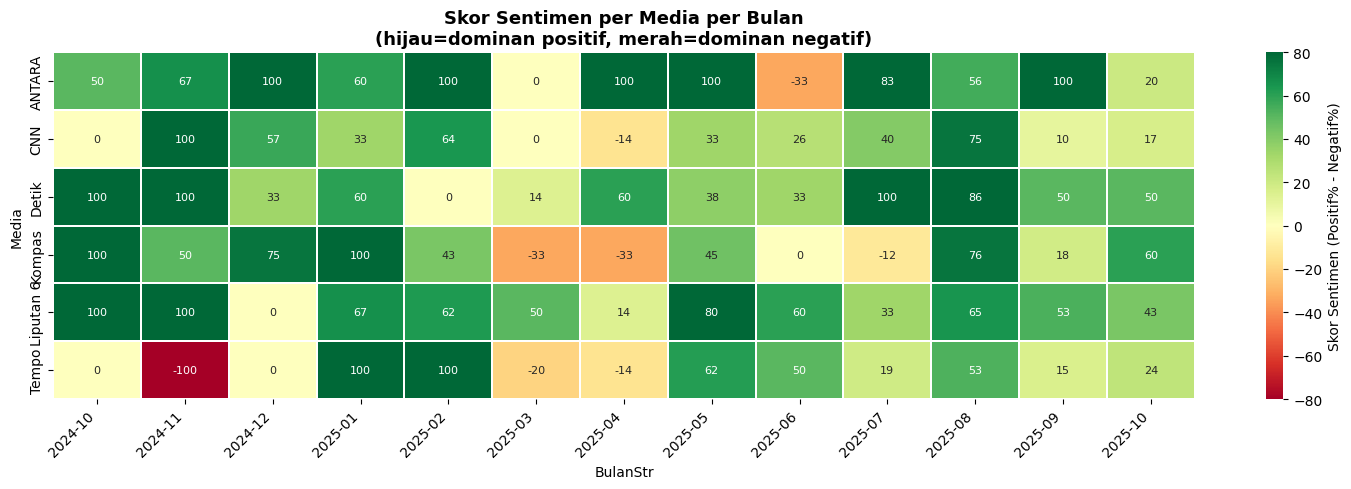

In [ ]:
# Heatmap skor sentimen per media x bulan
media_bulan = df_all.groupby(['Media','BulanStr','PrediksiLabel']).size().unstack(fill_value=0)
for kol in ['Positif','Netral','Negatif']:
    if kol not in media_bulan.columns: media_bulan[kol] = 0
media_bulan['Total'] = media_bulan.sum(axis=1)
media_bulan['Skor']  = (media_bulan['Positif'] - media_bulan['Negatif']) / media_bulan['Total'] * 100
pivot = media_bulan['Skor'].unstack('BulanStr').fillna(0)

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot, cmap='RdYlGn', center=0, vmin=-80, vmax=80,
            annot=True, fmt='.0f', annot_kws={'size': 8},
            linewidths=0.3, linecolor='white', ax=ax,
            cbar_kws={'label': 'Skor Sentimen (Positif% - Negatif%)'})
ax.set_title('Skor Sentimen per Media per Bulan\n(hijau=dominan positif, merah=dominan negatif)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '09_heatmap_media_bulan.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Highlight pergeseran signifikan
print('ANALISIS PERGESERAN SENTIMEN SIGNIFIKAN:')
print('=' * 55)
delta_pos = temporal['%Positif'].diff().dropna()
delta_neg = temporal['%Negatif'].diff().dropna()
print('\n5 Perubahan terbesar sentimen POSITIF:')
print(delta_pos.sort_values(key=abs, ascending=False).head(5))
print('\n5 Perubahan terbesar sentimen NEGATIF:')
print(delta_neg.sort_values(key=abs, ascending=False).head(5))
print(f'\nBulan sentimen POSITIF tertinggi: {temporal["%Positif"].idxmax()} ({temporal["%Positif"].max():.1f}%)')
print(f'Bulan sentimen NEGATIF tertinggi: {temporal["%Negatif"].idxmax()} ({temporal["%Negatif"].max():.1f}%)')


ANALISIS PERGESERAN SENTIMEN SIGNIFIKAN:

5 Perubahan terbesar sentimen POSITIF:
BulanStr
2025-03   -38.198758
2025-08    30.357143
2025-05    26.827309
2025-09   -22.857143
2025-06   -18.564398
Name: %Positif, dtype: float64

5 Perubahan terbesar sentimen NEGATIF:
BulanStr
2025-03    27.639752
2025-05   -23.132530
2024-11    18.750000
2025-09    15.654762
2025-08   -11.904762
Name: %Negatif, dtype: float64

Bulan sentimen POSITIF tertinggi: 2024-10 (85.7%)
Bulan sentimen NEGATIF tertinggi: 2025-03 (42.9%)


---
## Bagian 9 - Analisis Sentimen per Media

Bab 4.4: Karakteristik Tone per Media Nasional

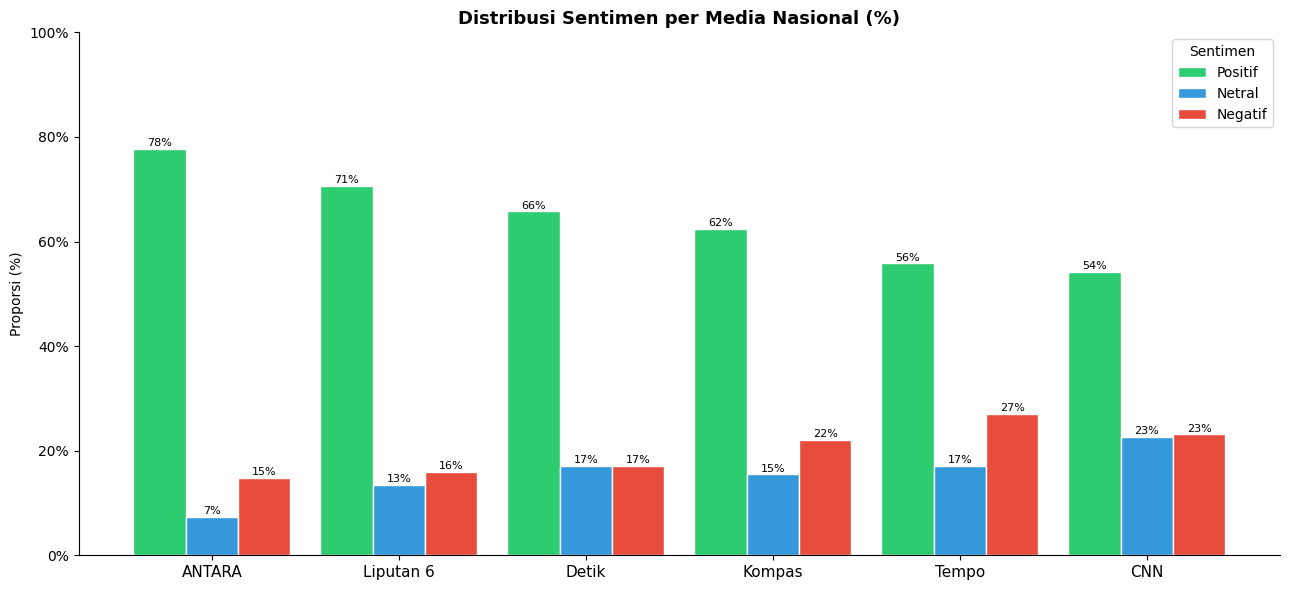

PrediksiLabel,Positif,Netral,Negatif,Total,%Positif,%Netral,%Negatif
Media,,,,,,,
ANTARA,42,4,8,54,77.8,7.4,14.8
CNN,117,49,50,216,54.2,22.7,23.1
Detik,50,13,13,76,65.8,17.1,17.1
Kompas,133,33,47,213,62.4,15.5,22.1
Liputan 6,142,27,32,201,70.6,13.4,15.9
Tempo,134,41,65,240,55.8,17.1,27.1


In [ ]:
media_sentimen = df_all.groupby(['Media','PrediksiLabel']).size().unstack(fill_value=0)
for kol in ['Positif','Netral','Negatif']:
    if kol not in media_sentimen.columns: media_sentimen[kol] = 0
media_sentimen = media_sentimen[['Positif','Netral','Negatif']]
media_sentimen['Total']    = media_sentimen.sum(axis=1)
media_sentimen['%Positif'] = media_sentimen['Positif'] / media_sentimen['Total'] * 100
media_sentimen['%Netral']  = media_sentimen['Netral']  / media_sentimen['Total'] * 100
media_sentimen['%Negatif'] = media_sentimen['Negatif'] / media_sentimen['Total'] * 100

media_list = media_sentimen.dropna().sort_values('%Positif', ascending=False).index.tolist()
plot_data  = media_sentimen.loc[media_list, ['%Positif','%Netral','%Negatif']]

fig, ax = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(media_list))
width = 0.28
for i, (kol, label) in enumerate([('%Positif','Positif'),('%Netral','Netral'),('%Negatif','Negatif')]):
    bars = ax.bar(x_pos + (i-1)*width, plot_data[kol], width,
                  label=label, color=WARNA[label], edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        if h > 3:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.0f}%',
                    ha='center', fontsize=8)
ax.set_title('Distribusi Sentimen per Media Nasional (%)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos); ax.set_xticklabels(media_list, fontsize=11)
ax.set_ylabel('Proporsi (%)'); ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Sentimen')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '10_sentimen_per_media.png'), dpi=150, bbox_inches='tight')
plt.show()
display(media_sentimen.round(1))


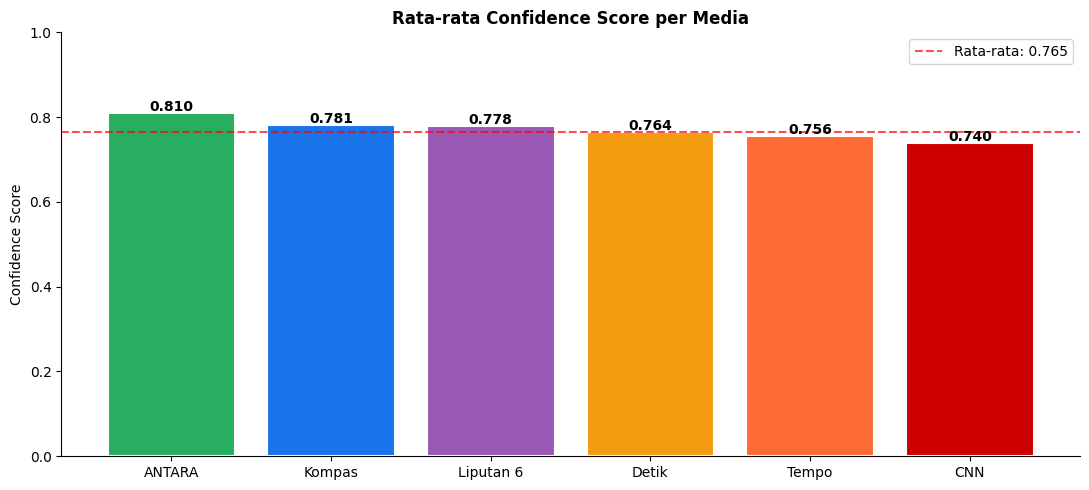

In [ ]:
# Confidence per media
fig, ax = plt.subplots(figsize=(11, 5))
conf_per_media = df_all.groupby('Media')['Confidence'].mean().sort_values(ascending=False)
bars = ax.bar(conf_per_media.index, conf_per_media.values,
              color=[WARNA_MEDIA.get(m,'#95A5A6') for m in conf_per_media.index],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, conf_per_media.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Rata-rata Confidence Score per Media', fontsize=12, fontweight='bold')
ax.set_ylabel('Confidence Score'); ax.set_ylim(0, 1)
ax.axhline(df_all['Confidence'].mean(), color='red', linestyle='--', alpha=0.7,
           label=f'Rata-rata: {df_all["Confidence"].mean():.3f}')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DIR, '11_confidence_per_media.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Bagian 10 - Ringkasan Hasil & Bahan Bab 5 (Kesimpulan)

In [ ]:
dist     = df_all['PrediksiLabel'].value_counts()
total_ok = len(df_all)
dom      = dist.idxmax()

media_pos = media_sentimen['%Positif'].idxmax()
media_neg = media_sentimen['%Negatif'].idxmax()
bln_pos   = temporal['%Positif'].idxmax()
bln_neg   = temporal['%Negatif'].idxmax()

print('=' * 60)
print('   RINGKASAN HASIL - BAHAN PENULISAN BAB 5')
print('=' * 60)
print(f'''
[DATASET]
  Total artikel   : {total_ok}
  Periode         : Oktober 2024 - Oktober 2025
  Jumlah media    : {df_all['Media'].nunique()}

[PERFORMA MODEL IndoBERT]
  Akurasi test set: {acc*100:.2f}%
  F1-Score (W)    : {f1*100:.2f}%
  Presisi (W)     : {prec*100:.2f}%
  Recall (W)      : {rec*100:.2f}%

[DISTRIBUSI SENTIMEN KESELURUHAN]
  Positif  : {dist.get('Positif',0)} ({dist.get('Positif',0)/total_ok*100:.1f}%)
  Netral   : {dist.get('Netral',0)} ({dist.get('Netral',0)/total_ok*100:.1f}%)
  Negatif  : {dist.get('Negatif',0)} ({dist.get('Negatif',0)/total_ok*100:.1f}%)
  Dominan  : {dom}

[ANALISIS TEMPORAL]
  Sentimen positif tertinggi : {bln_pos} ({temporal['%Positif'].max():.1f}%)
  Sentimen negatif tertinggi : {bln_neg} ({temporal['%Negatif'].max():.1f}%)

[ANALISIS PER MEDIA]
  Media paling positif : {media_pos} ({media_sentimen.loc[media_pos,'%Positif']:.1f}%)
  Media paling negatif : {media_neg} ({media_sentimen.loc[media_neg,'%Negatif']:.1f}%)
''')
print('=' * 60)


   RINGKASAN HASIL - BAHAN PENULISAN BAB 5

[DATASET]
  Total artikel   : 1001
  Periode         : Oktober 2024 - Oktober 2025
  Jumlah media    : 6

[PERFORMA MODEL IndoBERT]
  Akurasi test set: 74.00%
  F1-Score (W)    : 73.13%
  Presisi (W)     : 75.05%
  Recall (W)      : 74.00%

[DISTRIBUSI SENTIMEN KESELURUHAN]
  Positif  : 618 (61.7%)
  Netral   : 168 (16.8%)
  Negatif  : 215 (21.5%)
  Dominan  : Positif

[ANALISIS TEMPORAL]
  Sentimen positif tertinggi : 2024-10 (85.7%)
  Sentimen negatif tertinggi : 2025-03 (42.9%)

[ANALISIS PER MEDIA]
  Media paling positif : ANTARA (77.8%)
  Media paling negatif : Tempo (27.1%)



In [ ]:
# Error analysis - contoh prediksi salah
df_eval = df_labeled.copy()
eval_preds, _ = prediksi_sentimen(df_eval['TeksClean'].tolist())
df_eval['PrediksiLabel'] = [ID2LABEL[p] for p in eval_preds]
df_eval['Benar'] = df_eval['Label'] == df_eval['PrediksiLabel']
salah = df_eval[~df_eval['Benar']]

print(f'Total prediksi salah: {len(salah)} dari {len(df_eval)} ({len(salah)/len(df_eval)*100:.1f}%)')
print('\nContoh 5 prediksi salah:')
for _, row in salah.head(5).iterrows():
    print(f'  Judul    : {row["Judul"][:65]}')
    print(f'  Aktual   : {row["Label"]:8s} | Prediksi: {row["PrediksiLabel"]}')
    print(f'  Teks     : {row["Teks"][:90]}...')
    print()


Total prediksi salah: 191 dari 1000 (19.1%)

Contoh 5 prediksi salah:
  Judul    : Menakar Kondisi Ekonomi Indonesia 2025 di Bawah Pemerintahan Baru
  Aktual   : Netral   | Prediksi: Positif
  Teks     : Menakar Kondisi Ekonomi Indonesia 2025 di Bawah Pemerintahan Baru. Pemerintahan baru dinil...

  Judul    : BPS Catat Ekonomi Indonesia Tumbuh 4,95 Persen YoY pada Triwulan 
  Aktual   : Netral   | Prediksi: Positif
  Teks     : BPS Catat Ekonomi Indonesia Tumbuh 4,95 Persen YoY pada Triwulan III. Plt. Kepala Badan Pu...

  Judul    : Tantangan dan Peluang RI Kejar Target Pertumbuhan Ekonomi 8 Perse
  Aktual   : Netral   | Prediksi: Negatif
  Teks     : Tantangan dan Peluang RI Kejar Target Pertumbuhan Ekonomi 8 Persen. Target Presiden Prabow...

  Judul    : Judi online dan kedaruratan sosial ekonomi bangsa
  Aktual   : Netral   | Prediksi: Negatif
  Teks     : Judi online dan kedaruratan sosial ekonomi bangsa. Judi online dianggap sebagai “darurat s...

  Judul    : Sri Mulyani Ingin

---
## Checklist Output untuk Bab 4 & 5

| # | File Output | Digunakan di |
|---|-------------|--------------|
| 1 | `01_distribusi_label.png` | Bab 4.1 |
| 2 | `02_distribusi_per_media.png` | Bab 4.1 |
| 3 | `03_distribusi_bulanan.png` | Bab 4.1 |
| 4 | `04_panjang_teks.png` | Bab 4.1 |
| 5 | `05_wordcloud.png` | Bab 4.1 |
| 6 | `06_training_history.png` | Bab 4.2 |
| 7 | `07_confusion_matrix.png` | Bab 4.2 |
| 8 | `08_tren_temporal.png` | Bab 4.3 |
| 9 | `09_heatmap_media_bulan.png` | Bab 4.3 |
| 10 | `10_sentimen_per_media.png` | Bab 4.4 |
| 11 | `11_confidence_per_media.png` | Bab 4.4 |
| 12 | `Hasil_Sentimen_Berita_Ekonomi.xlsx` | Lampiran |
| 13 | `model-indobert-sentimen-final/` | Lampiran |

Semua file tersimpan otomatis di **Google Drive > file skripsi**